In [2]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
import arviz as az

from cmdstanpy import CmdStanModel

C:\Users\ronin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Data Creation

As adapted from the slides, we use the same old and new items.

There are 20 items each in both the "old" set and the "new" set.

We now create the deta as follows:

In [3]:
# Define a local RNG with a fixed seed
global_rng = np.random.default_rng(7)

true_probs = {
    "d_true": 0.7,
    "g_true": 0.3
}

# 20 words to remember, and a "test set" of 20 words...
N_old = 20
N_new = 20

# 1HT category probabilities (taken from slide12)...
#  these probabilities are "less rich" than the 2HT but will be used in the stan model
p_old_given_old = true_probs["d_true"] + (1 - true_probs["d_true"])*true_probs["g_true"]
p_new_given_old = (1 - true_probs["d_true"])*(1 - true_probs["g_true"])

p_old_given_new = true_probs["g_true"]
p_new_given_new = (1 - true_probs["g_true"])

# 2HT category probabilities (taken from slide12)...
p_old_given_old = true_probs["d_true"] + (1 - true_probs["d_true"])*true_probs["g_true"]
p_new_given_old = (1 - true_probs["d_true"])*(1 - true_probs["g_true"])

p_old_given_new = (1 - true_probs["d_true"])*true_probs["g_true"]
p_new_given_new = true_probs["d_true"] + (1 - true_probs["d_true"])*(1 - true_probs["g_true"])

# simulating data...
y_old = global_rng.multinomial(
    n=N_old,
    pvals=[p_old_given_old, p_new_given_old]
)

y_new = global_rng.multinomial(
    n=N_new,
    pvals=[p_old_given_new, p_new_given_new]
)

# "confusion matrix"...
print("Responses for old items [old_response, new_response]:", y_old)
print("Responses for new items [old_response, new_response]:", y_new)

Responses for old items [old_response, new_response]: [15  5]
Responses for new items [old_response, new_response]: [ 3 17]


## Modeling Multiple Responses via a Multinomial Likelihood

We will first build a baseline model that will estimate the underlying (latent) probabilities from the observed frequency data.

### Model Fitting

In [4]:
# Prepare data
data_dict = {
    "N_old": N_old,
    "N_new": N_new,
    "y_old": y_old,
    "y_new": y_new
}

# Compile model
model_1ht = CmdStanModel(stan_file="models/q2_mpt_1ht.stan")
fit_1ht = model_1ht.sample(data=data_dict, chains=4, iter_sampling=2500, iter_warmup=1000)

model_2ht = CmdStanModel(stan_file="models/q2_mpt_2ht.stan")
fit_2ht = model_2ht.sample(data=data_dict, chains=4, iter_sampling=2500, iter_warmup=1000)


13:13:23 - cmdstanpy - INFO - compiling stan file C:\Users\ronin\OneDrive\Pictures\cogmod\CogMod-HWs\hw4\models\q2_mpt_1ht.stan to exe file C:\Users\ronin\OneDrive\Pictures\cogmod\CogMod-HWs\hw4\models\q2_mpt_1ht.exe
13:14:41 - cmdstanpy - INFO - compiled model executable: C:\Users\ronin\OneDrive\Pictures\cogmod\CogMod-HWs\hw4\models\q2_mpt_1ht.exe
13:14:42 - cmdstanpy - INFO - CmdStan start processing
chain 1:   0%|          | 0/3500 [00:00<?, ?it/s, (Warmup)]


chain 1:  29%|██▊       | 1000/3500 [00:00<00:00, 16352.38it/s, (Sampling)]


chain 1:  51%|█████▏    | 1800/3500 [00:00<00:00, 17787.42it/s, (Sampling)]


chain 2: 100%|██████████| 3500/3500 [00:00<00:00, 17120.45it/s, (Sampling completed)]

chain 3: 100%|██████████| 3500/3500 [00:00<00:00, 17289.66it/s, (Sampling completed)]


chain 4: 100%|██████████| 3500/3500 [00:00<00:00, 17461.11it/s, (Sampling completed)]


13:14:42 - cmdstanpy - INFO - CmdStan done processing.


13:14:43 - cmdstanpy - INFO - compiling stan file C:\Users\ronin\OneDrive\Pictures\cogmod\CogMod-HWs\hw4\models\q2_mpt_2ht.stan to exe file C:\Users\ronin\OneDrive\Pictures\cogmod\CogMod-HWs\hw4\models\q2_mpt_2ht.exe
13:15:01 - cmdstanpy - INFO - compiled model executable: C:\Users\ronin\OneDrive\Pictures\cogmod\CogMod-HWs\hw4\models\q2_mpt_2ht.exe
13:15:02 - cmdstanpy - INFO - CmdStan start processing
chain 1:   0%|          | 0/3500 [00:00<?, ?it/s, (Warmup)]



chain 1:  29%|██▊       | 1000/3500 [00:00<00:00, 17238.66it/s, (Sampling)]

chain 1:  57%|█████▋    | 2000/3500 [00:00<00:00, 19894.34it/s, (Sampling)]


chain 2: 100%|██████████| 3500/3500 [00:00<00:00, 18931.76it/s, (Sampling completed)]

chain 3: 100%|██████████| 3500/3500 [00:00<00:00, 18728.78it/s, (Sampling completed)]


chain 4: 100%|██████████| 3500/3500 [00:00<00:00, 18728.75it/s, (Sampling completed)]


13:15:02 - cmdstanpy - INFO - CmdStan done processing.


### Model Inspection (1HT)

In [5]:
# Estimation summary, convergence, and efficiency diagnostics
fit_1ht.summary()

,Mean,MCSE,StdDev,MAD,5%,50%,95%,ESS_bulk,ESS_tail,ESS_bulk/s,R_hat
lp__,-24.259100,0.016950,1.048700,0.751386,-26.354700,-23.936000,-23.259500,4233.19,5110.23,9084.10,0.999953
d,0.658831,0.001596,0.123360,0.121735,0.437633,0.671028,0.838379,6150.93,5659.40,13199.40,1.000170
g,0.190984,0.001061,0.083599,0.081873,0.072568,0.180343,0.342488,6036.65,5370.22,12954.20,0.999946
old_tree[1],0.727193,0.001072,0.093077,0.094888,0.562982,0.733865,0.867755,7435.15,6655.37,15955.30,1.000250
old_tree[2],0.272807,0.001072,0.093077,0.094888,0.132245,0.266135,0.437018,7435.15,6655.37,15955.30,1.000250
new_tree[1],0.190984,0.001061,0.083599,0.081873,0.072568,0.180343,0.342488,6036.65,5370.22,12954.20,0.999946
new_tree[2],0.809016,0.001061,0.083599,0.081873,0.657512,0.819657,0.927432,6036.65,5370.22,12954.20,0.999946
pred_y_old[1],14.540400,0.028964,2.685380,2.965200,10.000000,15.000000,19.000000,8619.76,9386.38,18497.30,1.000090
pred_y_old[2],5.459600,0.028964,2.685380,2.965200,1.000000,5.000000,10.000000,8619.76,9386.38,18497.30,1.000090
pred_y_new[1],3.864600,0.027865,2.415380,2.965200,0.000000,4.000000,8.000000,7540.46,8116.87,16181.20,1.000010


In [6]:
fit_1ht.draws_pd().head()

,chain__,iter__,draw__,lp__,accept_stat__,stepsize__,treedepth__,n_leapfrog__,divergent__,energy__,...,g,old_tree[1],old_tree[2],new_tree[1],new_tree[2],pred_y_old[1],pred_y_old[2],pred_y_new[1],pred_y_new[2],log_likelihood
0,1.0,1.0,1.0,-23.326704,1.000000,0.811214,2.0,3.0,0.0,24.991587,...,0.188358,0.775579,0.224421,0.188358,0.811642,15.0,5.0,4.0,16.0,-3.151766
1,1.0,2.0,2.0,-24.148191,0.856180,0.811214,3.0,7.0,0.0,24.954439,...,0.138106,0.606841,0.393159,0.138106,0.861894,9.0,11.0,1.0,19.0,-3.938183
2,1.0,3.0,3.0,-23.269240,0.996443,0.811214,2.0,3.0,0.0,24.207108,...,0.211300,0.713035,0.286965,0.211300,0.788700,12.0,8.0,5.0,15.0,-3.326419
3,1.0,4.0,4.0,-23.252041,0.815593,0.811214,2.0,3.0,0.0,24.449927,...,0.162477,0.738173,0.261827,0.162477,0.837523,19.0,1.0,5.0,15.0,-3.032243
4,1.0,5.0,5.0,-23.482201,0.938884,0.811214,2.0,3.0,0.0,23.883082,...,0.131656,0.749817,0.250183,0.131656,0.868344,15.0,5.0,4.0,16.0,-3.041600


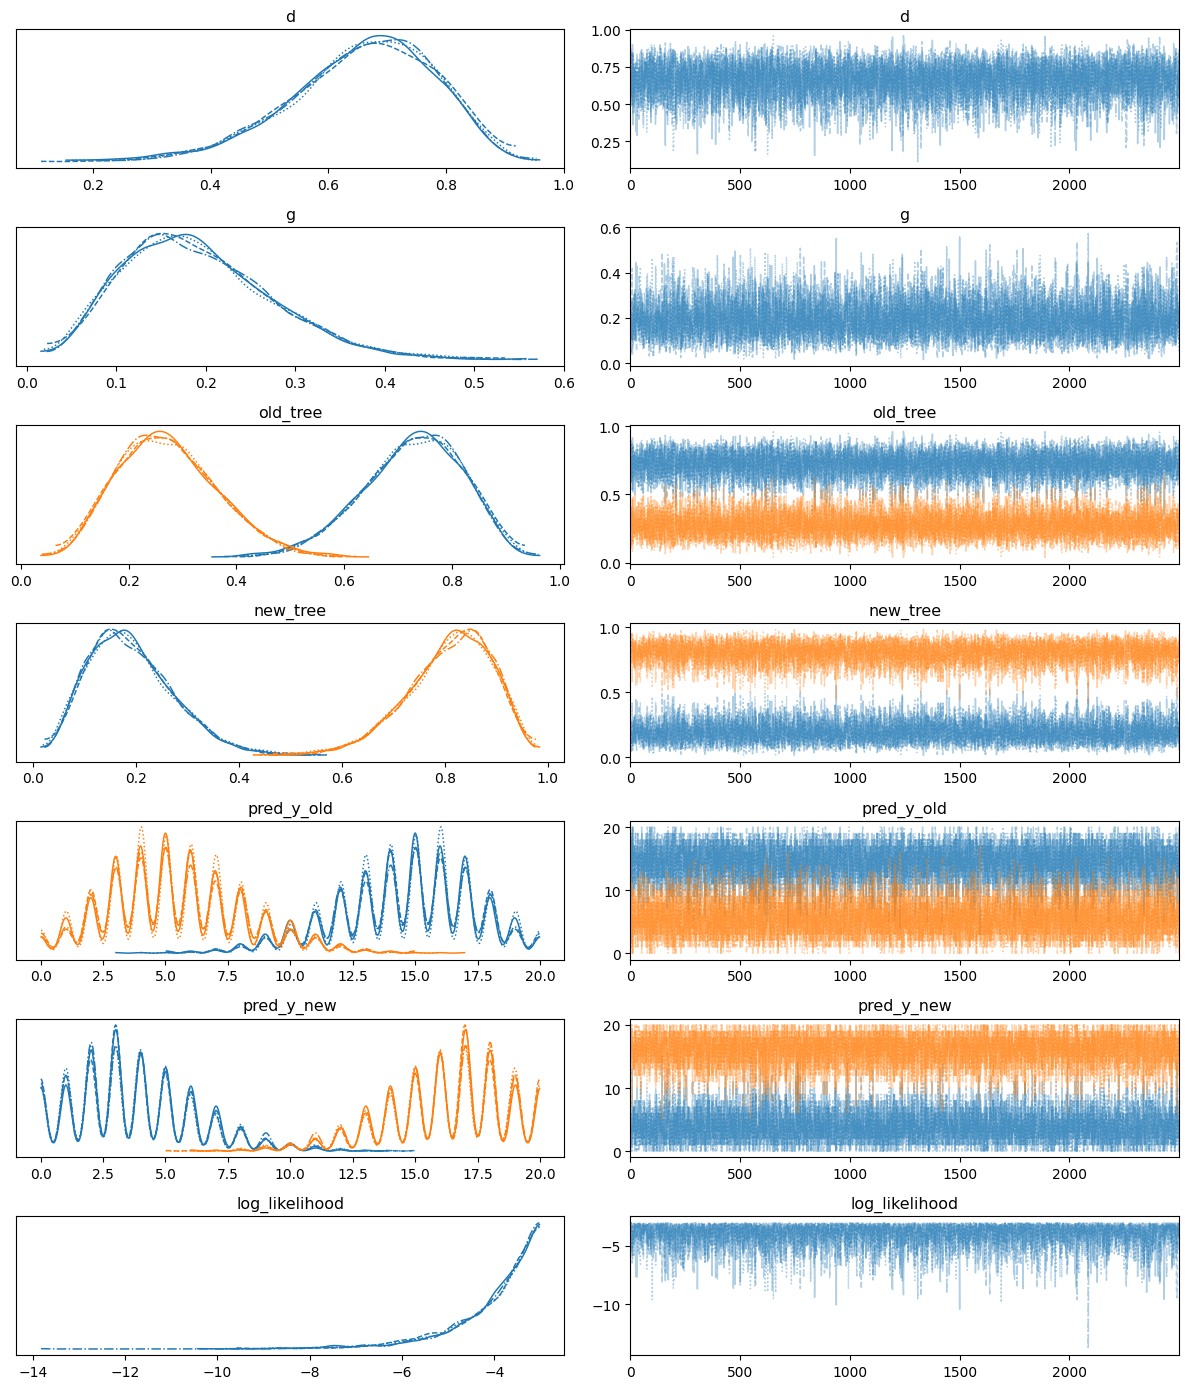

In [7]:
# Traceplots and marginals - visual convergence checks
axarr = az.plot_trace(fit_1ht)
plt.tight_layout()

### Model Inspection (2HT)

In [8]:
# Estimation summary, convergence, and efficiency diagnostics
fit_2ht.summary()

,Mean,MCSE,StdDev,MAD,5%,50%,95%,ESS_bulk,ESS_tail,ESS_bulk/s,R_hat
lp__,-23.621600,0.016795,1.087870,0.757411,-25.779600,-23.283800,-22.616200,4750.35,5272.96,10064.3,1.001130
d,0.577652,0.001321,0.120700,0.120950,0.367131,0.585373,0.761488,8728.35,5808.48,18492.3,1.000520
g,0.399648,0.001593,0.136724,0.140825,0.182640,0.394938,0.635474,7308.19,6195.75,15483.5,1.000710
old_tree[1],0.746893,0.000984,0.091196,0.090632,0.583709,0.754478,0.882459,8710.35,6619.43,18454.1,1.000900
old_tree[2],0.253107,0.000984,0.091196,0.090632,0.117541,0.245522,0.416291,8710.35,6619.43,18454.1,1.000900
new_tree[1],0.169241,0.000898,0.077146,0.075469,0.060355,0.159157,0.310141,7278.34,6252.43,15420.2,1.000110
new_tree[2],0.830759,0.000898,0.077146,0.075469,0.689859,0.840843,0.939645,7278.34,6252.43,15420.2,1.000110
pred_y_old[1],14.924800,0.026996,2.629720,2.965200,10.000000,15.000000,19.000000,9540.85,9448.14,20213.7,1.000710
pred_y_old[2],5.075200,0.026996,2.629720,2.965200,1.000000,5.000000,10.000000,9540.85,9448.14,20213.7,1.000710
pred_y_new[1],3.382700,0.023750,2.225880,1.482600,0.000000,3.000000,8.000000,8880.28,8740.55,18814.2,0.999957


In [9]:
fit_2ht.draws_pd().head()

,chain__,iter__,draw__,lp__,accept_stat__,stepsize__,treedepth__,n_leapfrog__,divergent__,energy__,...,g,old_tree[1],old_tree[2],new_tree[1],new_tree[2],pred_y_old[1],pred_y_old[2],pred_y_new[1],pred_y_new[2],log_likelihood
0,1.0,1.0,1.0,-24.734558,0.914050,0.957838,1.0,1.0,0.0,24.941818,...,0.671549,0.896906,0.103094,0.210785,0.789215,18.0,2.0,7.0,13.0,-4.999936
1,1.0,2.0,2.0,-23.878551,0.994658,0.957838,2.0,3.0,0.0,25.039356,...,0.250728,0.592242,0.407758,0.136447,0.863553,13.0,7.0,2.0,18.0,-4.124732
2,1.0,3.0,3.0,-25.053194,0.733066,0.957838,2.0,3.0,0.0,27.464005,...,0.238545,0.837367,0.162633,0.050949,0.949051,17.0,3.0,3.0,17.0,-4.875832
3,1.0,4.0,4.0,-23.999152,1.000000,0.957838,2.0,3.0,0.0,25.055636,...,0.207423,0.758235,0.241765,0.063272,0.936728,14.0,6.0,1.0,19.0,-3.954838
4,1.0,5.0,5.0,-23.985659,0.995467,0.957838,2.0,7.0,0.0,24.141456,...,0.595989,0.789076,0.210924,0.311151,0.688849,13.0,7.0,8.0,12.0,-4.485930


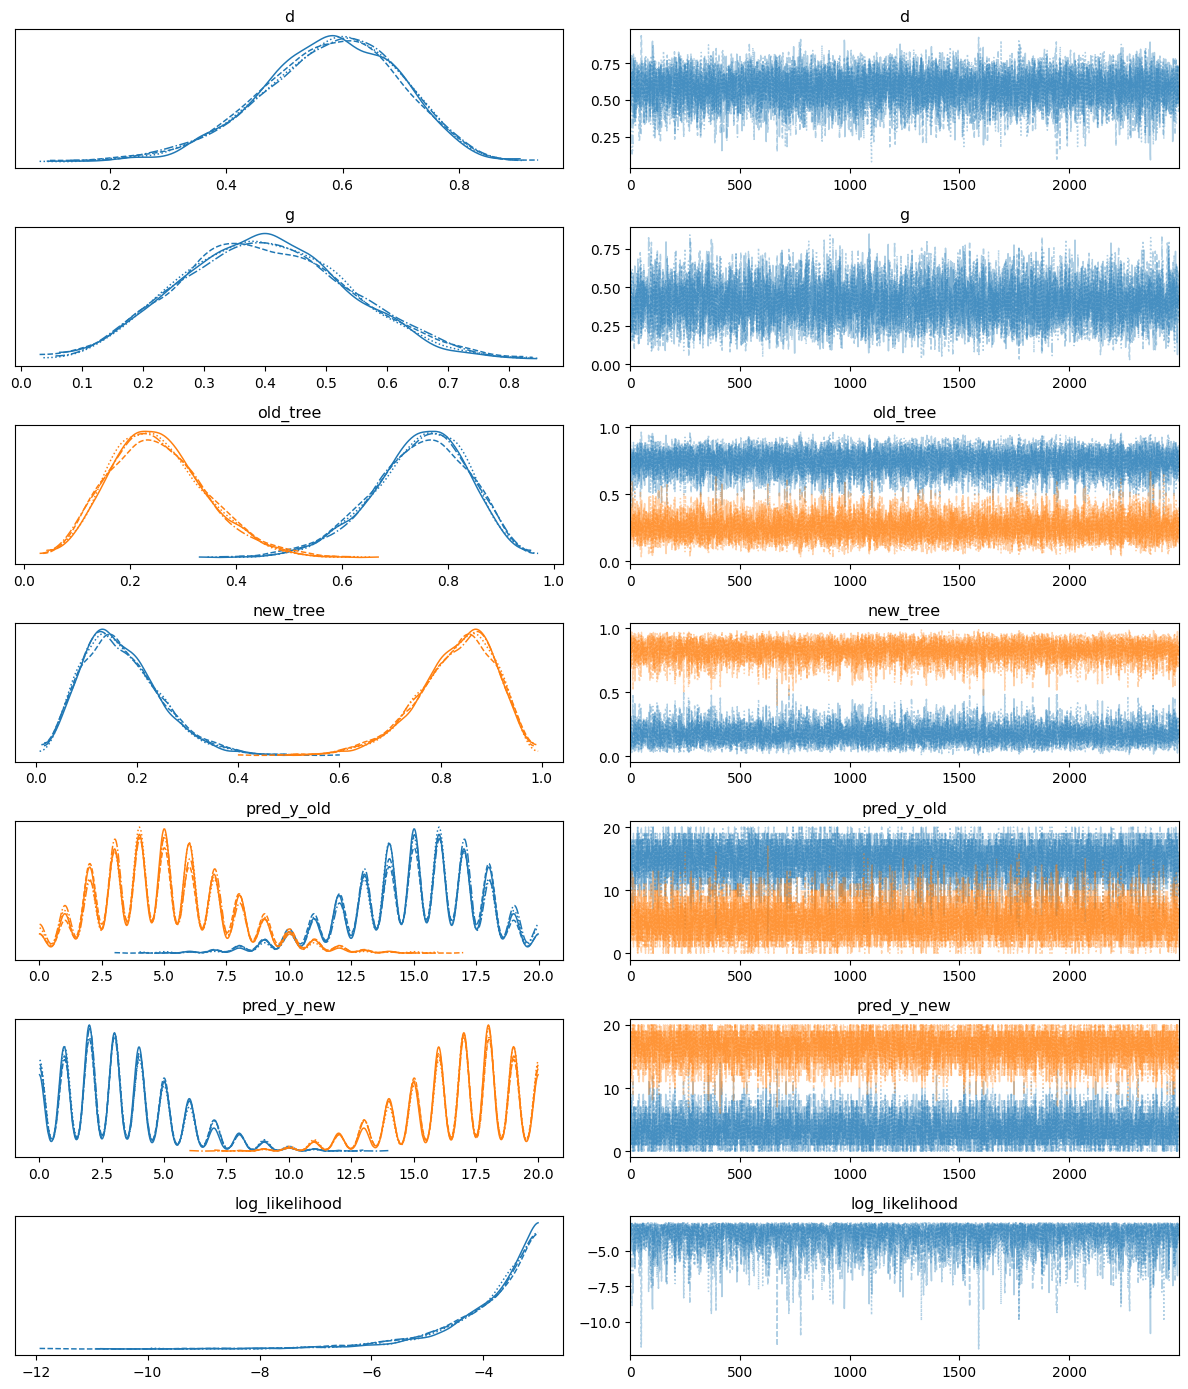

In [10]:
# Traceplots and marginals - visual convergence checks
axarr = az.plot_trace(fit_2ht)
plt.tight_layout()